In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("washington_ultimate.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12017 entries, 0 to 12016
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   zip                 12014 non-null  float64
 1   type                12017 non-null  object 
 2   year_built          11157 non-null  float64
 3   listPrice           10325 non-null  float64
 4   lastSoldPrice       12002 non-null  float64
 5   list_to_sold_ratio  10310 non-null  float64
 6   sqft                11145 non-null  float64
 7   price_per_sqft      11121 non-null  float64
 8   stories             10506 non-null  float64
 9   beds                11085 non-null  float64
 10  baths               11533 non-null  float64
 11  baths_full          10768 non-null  float64
 12  baths_full_calc     11004 non-null  float64
 13  garage              2363 non-null   float64
 14  sanitized_text      10298 non-null  object 
dtypes: float64(13), object(2)
memory usage: 1.4+ MB


In [5]:
df.head(1000000)

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text
0,99156.0,single_family,1997.0,875054.0,875085.0,1.0000,2710.0,322.91,1.0,3.0,3.0,2.0,2.0,3.0,"2, 700+ sq ft residence features 3 beds, 2.5 b..."
1,99006.0,single_family,1900.0,349989.0,347902.0,0.9940,1460.0,238.29,2.0,3.0,2.0,2.0,2.0,NaN,"this beautifully remodeled 3-bedroom, 2-bath h..."
2,98843.0,single_family,2017.0,2594917.0,2539927.0,0.9788,3770.0,673.72,2.0,4.0,4.0,1.0,4.0,NaN,this stunning home offers 130 feet of prime fr...
3,98311.0,single_family,1990.0,749072.0,744599.0,0.9940,4250.0,175.20,2.0,3.0,4.0,1.0,2.0,NaN,[ADDRESS REDACTED]yle home w/ 3bd /2.75BA /3ca...
4,98102.0,single_family,1926.0,1790072.0,1790076.0,1.0000,3500.0,511.45,2.0,3.0,3.0,1.0,2.0,NaN,the 100-year-old home sits privately above the...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12012,99218.0,single_family,1978.0,524957.0,504906.0,0.9618,3270.0,154.41,NaN,4.0,3.0,3.0,3.0,2.0,perfect location in one of North Spokane's mos...
12013,98251.0,single_family,1999.0,599927.0,589926.0,0.9833,1710.0,344.99,2.0,3.0,3.0,2.0,2.0,NaN,custom built custom built home features covere...
12014,98251.0,single_family,2019.0,514909.0,512575.0,0.9955,1810.0,283.19,2.0,3.0,2.0,1.0,2.0,NaN,open great-room design with vaulted tongue & g...
12015,98258.0,single_family,1993.0,599874.0,624935.0,1.0418,1090.0,573.33,1.0,3.0,2.0,2.0,2.0,NaN,"the 3-bedroom, 2-bath home offers a highly des..."


In [7]:
df.isnull().sum()

zip                      3
type                     0
year_built             860
listPrice             1692
lastSoldPrice           15
list_to_sold_ratio    1707
sqft                   872
price_per_sqft         896
stories               1511
beds                   932
baths                  484
baths_full            1249
baths_full_calc       1013
garage                9654
sanitized_text        1719
dtype: int64

In [8]:
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)

In [9]:
if 'sanitized_text' in df.columns:
    df = df.drop(columns=['sanitized_text'])

In [10]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

C:\Users\bhara\AppData\Local\Temp\ipykernel_27180\2907331251.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [12]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

In [14]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
df = df.drop_duplicates()

In [16]:
if 'year_built' in df.columns:
    df['property_age'] = 2026 - df['year_built']

if 'listPrice' in df.columns and 'lastSoldPrice' in df.columns:
    df['price_diff'] = df['listPrice'] - df['lastSoldPrice']

if 'listPrice' in df.columns and 'lastSoldPrice' in df.columns:
    df['price_ratio'] = df['listPrice'] / (df['lastSoldPrice'] + 1)

In [17]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [18]:
df.to_csv('final_cleaned_data.csv', index=False)

In [19]:
df.shape

(12017, 16)

In [21]:
df.head(12500)

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,property_age,price_diff,price_ratio
0,99156.0,single_family,1997.0,875054.0,875085.0,1.00000,2710.0,322.91,1.0,3.0,3.0,2.0,2.0,29.0,-31.0,0.999963
1,99006.0,single_family,1909.0,349989.0,347902.0,0.99400,1460.0,238.29,2.0,3.0,2.0,2.0,2.0,117.0,2087.0,1.005996
2,98843.0,single_family,2017.0,1222787.0,1462187.5,0.97880,3770.0,673.72,2.0,4.0,4.0,1.0,2.0,9.0,43901.0,1.021650
3,98311.0,single_family,1990.0,749072.0,744599.0,0.99400,3865.0,175.20,2.0,3.0,4.0,1.0,2.0,36.0,4473.0,1.006006
4,98102.0,single_family,1926.0,1222787.0,1462187.5,1.00000,3500.0,511.45,2.0,3.0,3.0,1.0,2.0,100.0,-4.0,0.999997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12012,99218.0,single_family,1978.0,524957.0,504906.0,0.96180,3270.0,154.41,2.0,4.0,3.0,3.0,2.0,48.0,20051.0,1.039710
12013,98251.0,single_family,1999.0,599927.0,589926.0,0.98330,1710.0,344.99,2.0,3.0,3.0,2.0,2.0,27.0,10001.0,1.016951
12014,98251.0,single_family,2019.0,514909.0,512575.0,0.99550,1810.0,283.19,2.0,3.0,2.0,1.0,2.0,7.0,2334.0,1.004552
12015,98258.0,single_family,1993.0,599874.0,624935.0,1.02525,1090.0,573.33,1.0,3.0,2.0,2.0,2.0,33.0,-25061.0,0.959897


In [22]:
df.isnull().sum()

zip                   0
type                  0
year_built            0
listPrice             0
lastSoldPrice         0
list_to_sold_ratio    0
sqft                  0
price_per_sqft        0
stories               0
beds                  0
baths                 0
baths_full            0
baths_full_calc       0
property_age          0
price_diff            0
price_ratio           0
dtype: int64

In [26]:
df.to_csv('final_cleaned_data.csv', index=False)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [28]:
if 'sanitized_text' in df.columns:
    df = df.drop(columns=['sanitized_text'])

In [29]:
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [30]:
target = 'listPrice'
X = df.drop(columns=[target])
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [32]:
y_pred = model.predict(X_test)

In [33]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Value": [mae, rmse, r2]
})

metrics

,Metric,Value
0,MAE,3126.561753
1,RMSE,19201.249009
2,R2 Score,0.995643


In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [42]:
if 'year_built' in df.columns:
    df['property_age'] = 2026 - df['year_built']

if 'lastSoldPrice' in df.columns:
    df['price_ratio'] = df['listPrice'] / (df['lastSoldPrice'] + 1)

In [43]:
target = 'listPrice'
X = df.drop(columns=[target])
y = df[target]

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [44]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])


In [45]:
from xgboost import XGBRegressor
import joblib

In [46]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [47]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [49]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [50]:
y_pred = pipeline.predict(X_test)

In [51]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [53]:
print("\n🔥 MODEL PERFORMANCE")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


🔥 MODEL PERFORMANCE
MAE  : 4099.90
RMSE : 11901.04
R2   : 0.9983


In [54]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')

In [56]:
print("\n Cross Validation R2 Scores:", cv_scores)
print(" Average CV Score:", np.mean(cv_scores))


 Cross Validation R2 Scores: [0.99884537 0.99901885 0.99922672 0.99893246 0.99808223]
 Average CV Score: 0.9988211242194215


In [57]:
model_fitted = pipeline.named_steps['model']


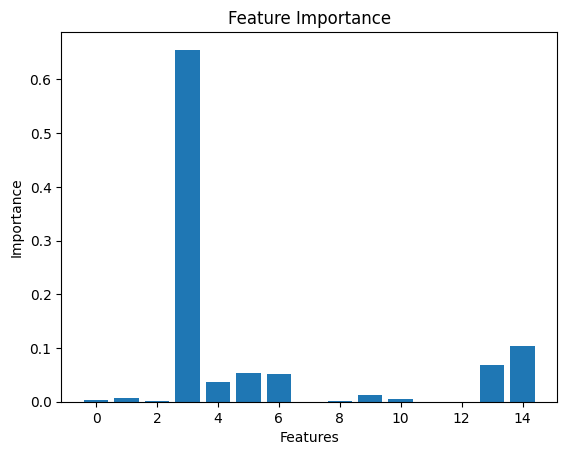

In [58]:
plt.figure()
plt.bar(range(len(model_fitted.feature_importances_)),
        model_fitted.feature_importances_)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [60]:
print("In Depth Analysis is Complete for this Dataset")

In Depth Analysis is Complete for this Dataset
